### 📚 Lesson 4.1: Word2Vec – Skip-gram (from scratch)

---

**Mày đã học gì rồi?**

* Mày đã biết: one-hot, BoW, TF-IDF, tokenization.
* Hiểu rằng BoW/TF-IDF không capture ngữ nghĩa → cần Word Embeddings.

---

#### ❓ Today's question

"How can a computer learn word meanings by predicting surrounding words from a given word?"

---

#### 💡 Key ideas

* **Distributional hypothesis**: từ nào xuất hiện trong cùng ngữ cảnh → có ý nghĩa gần nhau.
* **Skip-gram model**:

  * Input: 1 từ trung tâm (center word).
  * Output: các từ ngữ cảnh xung quanh (context words).
  * Ví dụ: `"I love NLP"` với window size = 1:

    * (center=`I`, context=`love`)
    * (center=`love`, context=`I`), (center=`love`, context=`NLP`)
    * (center=`NLP`, context=`love`)
* **Cấu trúc mạng đơn giản**:

  * Input one-hot → hidden layer (embedding matrix) → output softmax (predict context).
  * Embedding chính là weight matrix ở hidden layer.

👉 Ý tưởng: model học embedding vector sao cho nó giỏi predict context.

---

#### 📝 Practice Problem (from scratch)

**Task:**

* Input corpus: (`from .samples import corpus`)
* Step 1: Build vocab và training samples (center, context) với window size = 1.
* Step 2: Represent center word bằng one-hot.
* Step 3: Define forward pass: one-hot × embedding matrix → hidden → output (softmax).
* Step 4: Loss = cross-entropy với context word.

👉 Bài tập cho mày bây giờ: **Step 1**.
Hãy viết code tạo ra training pairs `(center, context)` từ corpus trên, window size = 1.

Ví dụ: với `"I love NLP"` → phải ra `[("I","love"), ("love","I"), ("love","NLP"), ("NLP","love")]`.

---

#### 🧩 Solution

In [1]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from samples import corpus

In [2]:
# Step 1:
vocabs = list(sorted(set(word for sent in corpus for word in sent.lower().split())))
num_vocabs = len(vocabs)

wsize = 1
dataset: list[tuple[str, str]] = []

for sent in corpus:
    words = sent.lower().split()
    for i in range(len(words)):
        dataset.extend(
            (words[i], words[j])
            for j in range(max(0, i-wsize), min(len(words), i+wsize+1))
            if i != j
        )

In [3]:
# Step 2:
word2idx = {}
for i, word in enumerate(vocabs):
    word2idx[word] = i

In [4]:
# Step 3:
def forward(center_word: str, W_in, W_out):
    logits = W_in[word2idx[center_word]] @ W_out
    logits = logits - logits.max()
    scores = np.exp(logits)
    return scores / scores.sum()

In [5]:
# Step 4:
def loss(center_word: str, context_word: str, W_in, W_out):
    probs = forward(center_word, W_in, W_out)
    return -np.log(probs[word2idx[context_word]])

In [6]:
# Step 5:
def train_step(center_word: str, context_word: str, W_in, W_out, lr: float):
    idx_center = word2idx[center_word]
    idx_context = word2idx[context_word]

    error = forward(center_word, W_in, W_out)
    error[idx_context] -= 1

    grad_W_out = np.outer(W_in[idx_center], error)
    grad_W_in = W_out @ error

    W_out -= lr * grad_W_out
    W_in[idx_center] -= lr * grad_W_in

In [7]:
embed_dim = 100
W_in = np.random.randn(num_vocabs, embed_dim) * 0.01
W_out = np.random.randn(embed_dim, num_vocabs) * 0.01

lr = 0.01
epochs = 2000

In [8]:
# Step 6:
loss_records = []
for _ in tqdm(range(epochs)):
    random.shuffle(dataset)

    current_loss = 0
    for center_word, context_word in dataset:
        current_loss += loss(center_word, context_word, W_in, W_out)
    loss_records.append(current_loss)

    for center_word, context_word in dataset:
        train_step(center_word, context_word, W_in, W_out, lr)

100%|██████████| 2000/2000 [00:16<00:00, 121.05it/s]


Final loss: 294.6935


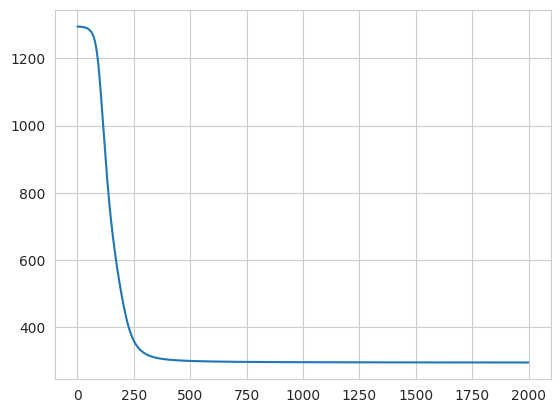

In [9]:
print(f"Final loss: {loss_records[-1]:.4f}")
sns.set_style('whitegrid')
sns.lineplot(x=range(epochs), y=loss_records)
plt.show()

---

#### 🚀 Bonus

In [10]:
def row_print(title, *args):
    print(f"| {title:>15}  |  {'  '.join(f'{arg:>15}' for arg in args)}  |")

In [11]:
print("Context prediction tests:")
print()

print("-" * 74)
row_print('center_word', 'ctx_1', 'ctx_2', 'ctx_3')
print("-" * 74)

orders = list(range(num_vocabs))

for center_word in random.sample(vocabs, 5):
    probs = forward(center_word, W_in, W_out)
    orders.sort(key=lambda i: -probs[i])

    row_print(center_word, *(vocabs[i] for i in orders[:3]))
    row_print('', *(round(100 * probs[i], 1) for i in orders[:3]))
print("-" * 74)

Context prediction tests:

--------------------------------------------------------------------------
|     center_word  |            ctx_1            ctx_2            ctx_3  |
--------------------------------------------------------------------------
|        word2vec  |              and             like           reduce  |
|                  |             99.7              0.1              0.1  |
|        language  |       processing          natural            large  |
|                  |             25.3             25.1             24.6  |
|    transformers  |              are        embedding           neural  |
|                  |             99.6              0.1              0.1  |
|             can  |           models      approximate         generate  |
|                  |             25.3             24.8             24.7  |
|         natural  |             love         language            allow  |
|                  |             50.1             49.6              0.1  